In [1]:
# ============================================================================
# CELL 1: Import Libraries
# ============================================================================
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ All libraries imported successfully")

2025-11-23 10:46:22.794075: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763894782.970717      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763894783.023939      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

✓ All libraries imported successfully


In [2]:
# ============================================================================
# CELL 2: Load and Explore Dataset
# ============================================================================
# Load dataset
df = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')

print("="*70)
print("DATASET INFORMATION")
print("="*70)
print(f"Dataset shape: {df.shape}")
print(f"\nFirst 3 rows:")
print(df.head(3))
print(f"\nSentiment distribution:\n{df['sentiment'].value_counts()}")
print(f"\nDataset info:")
print(df.info())

DATASET INFORMATION
Dataset shape: (50000, 2)

First 3 rows:
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB
None


In [3]:
# ============================================================================
# CELL 3: Data Preprocessing
# ============================================================================
print("\n" + "="*70)
print("DATA PREPROCESSING")
print("="*70)

# Preprocessing function
def clean_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', ' ', text)
    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    # Convert to lowercase
    text = text.lower()
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply preprocessing
df['cleaned_review'] = df['review'].apply(clean_text)

# Show example of cleaned text
print("\nExample of text cleaning:")
print("-"*70)
print("ORIGINAL:")
print(df['review'].iloc[0][:200] + "...")
print("\nCLEANED:")
print(df['cleaned_review'].iloc[0][:200] + "...")

# Convert sentiment to binary
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})
print(f"\n✓ Sentiment converted to binary (0=Negative, 1=Positive)")


DATA PREPROCESSING

Example of text cleaning:
----------------------------------------------------------------------
ORIGINAL:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo...

CLEANED:
one of the other reviewers has mentioned that after watching just oz episode you ll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its br...

✓ Sentiment converted to binary (0=Negative, 1=Positive)


In [4]:
# ============================================================================
# CELL 4: Train-Test Split (70-30)
# ============================================================================
print("\n" + "="*70)
print("TRAIN-TEST SPLIT (70% - 30%)")
print("="*70)

X = df['cleaned_review'].values
y = df['sentiment'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nTraining sentiment distribution: {np.bincount(y_train)}")
print(f"Testing sentiment distribution: {np.bincount(y_test)}")


TRAIN-TEST SPLIT (70% - 30%)
Total samples: 50000
Training samples: 35000 (70.0%)
Testing samples: 15000 (30.0%)

Training sentiment distribution: [17500 17500]
Testing sentiment distribution: [7500 7500]


In [5]:
# ============================================================================
# CELL 5: Tokenization and Padding
# ============================================================================
print("\n" + "="*70)
print("TOKENIZATION AND PADDING")
print("="*70)

max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post', truncating='post')

print(f"Maximum vocabulary size: {max_words}")
print(f"Actual vocabulary size: {len(tokenizer.word_index)}")
print(f"Maximum sequence length: {max_len}")
print(f"\nTraining data shape: {X_train_pad.shape}")
print(f"Testing data shape: {X_test_pad.shape}")

# Show example of tokenization
print(f"\nExample tokenization:")
print(f"Original text: {X_train[0][:100]}...")
print(f"Token sequence: {X_train_seq[0][:20]}...")
print(f"Padded sequence shape: {X_train_pad[0].shape}")


TOKENIZATION AND PADDING
Maximum vocabulary size: 10000
Actual vocabulary size: 85470
Maximum sequence length: 200

Training data shape: (35000, 200)
Testing data shape: (15000, 200)

Example tokenization:
Original text: if you want to see a true thriller rent this it s not from the director or screenwriter of scream do...
Token sequence: [45, 21, 182, 6, 66, 4, 293, 691, 808, 11, 8, 13, 24, 38, 2, 157, 41, 2650, 5, 2015]...
Padded sequence shape: (200,)


In [6]:
# ============================================================================
# CELL 6: Build LSTM Model
# ============================================================================
print("\n" + "="*70)
print("BUILDING LSTM MODEL")
print("="*70)

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(LSTM(32)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Build the model before counting parameters
model.build(input_shape=(None, max_len))

print("\nModel Architecture:")
model.summary()

# Count total parameters
total_params = model.count_params()
print(f"\n✓ Total parameters: {total_params:,}")


BUILDING LSTM MODEL


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1763894810.147238      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1763894810.147880      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,424,257 (5.43 MB)

 Trainable params: 1,424,257 (5.43 MB)

 Non-trainable params: 0 (0.00 B)


✓ Total parameters: 1,424,257


In [7]:
# ============================================================================
# CELL 7: Train Model
# ============================================================================
print("\n" + "="*70)
print("TRAINING MODEL")
print("="*70)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1)

# Train model
history = model.fit(
    X_train_pad, y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✓ Training completed!")


TRAINING MODEL
Epoch 1/10


I0000 00:00:1763894816.112377     109 cuda_dnn.cc:529] Loaded cuDNN version 90300


438/438 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.6288 - loss: 0.6160 - val_accuracy: 0.8504 - val_loss: 0.3536 - learning_rate: 0.0010
Epoch 2/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.8815 - loss: 0.3158 - val_accuracy: 0.8650 - val_loss: 0.3201 - learning_rate: 0.0010
Epoch 3/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9194 - loss: 0.2255 - val_accuracy: 0.8736 - val_loss: 0.3253 - learning_rate: 0.0010
Epoch 4/10
437/438 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9416 - loss: 0.1746
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9416 - loss: 0.1746 - val_accuracy: 0.8573 - val_loss: 0.3711 - learning_rate: 0.0010
Epoch 5/10
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9697 - loss: 0.0998 - val_accuracy: 0.8659 - val_loss: 0.5104 - learning_rate: 5.0000e-04
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

✓

In [8]:
# ============================================================================
# CELL 8: Evaluate Model on Test Set
# ============================================================================
print("\n" + "="*70)
print("MODEL EVALUATION ON TEST SET")
print("="*70)

test_loss, test_acc = model.evaluate(X_test_pad, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")


MODEL EVALUATION ON TEST SET

Test Accuracy: 0.8624 (86.24%)
Test Loss: 0.3209



PLOTTING TRAINING HISTORY


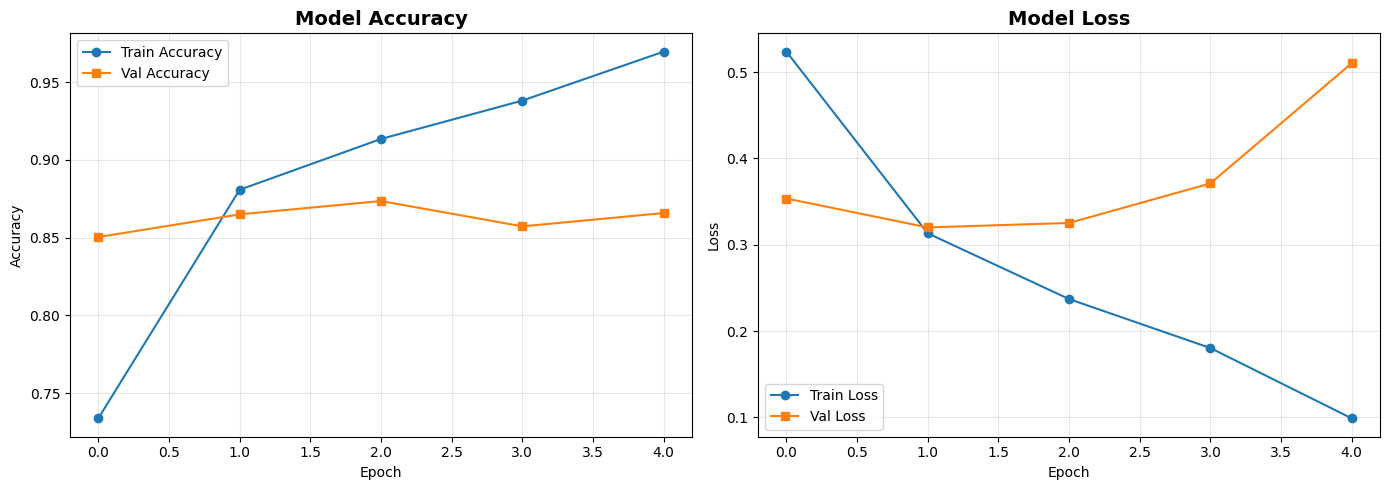

✓ Training history plotted


In [9]:
# ============================================================================
# CELL 9: Plot Training History
# ============================================================================
print("\n" + "="*70)
print("PLOTTING TRAINING HISTORY")
print("="*70)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s')
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train Loss', marker='o')
ax2.plot(history.history['val_loss'], label='Val Loss', marker='s')
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Training history plotted")

In [10]:
# ============================================================================
# CELL 10: Generate Predictions
# ============================================================================
print("\n" + "="*70)
print("GENERATING PREDICTIONS ON TEST SET")
print("="*70)

y_pred_prob = model.predict(X_test_pad, verbose=0).flatten()
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"✓ Predictions generated for {len(y_pred)} test samples")


GENERATING PREDICTIONS ON TEST SET
✓ Predictions generated for 15000 test samples


In [11]:
# ============================================================================
# CELL 11: Classification Report
# ============================================================================
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)

print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.90      0.81      0.86      7500
    Positive       0.83      0.91      0.87      7500

    accuracy                           0.86     15000
   macro avg       0.87      0.86      0.86     15000
weighted avg       0.87      0.86      0.86     15000




CONFUSION MATRIX


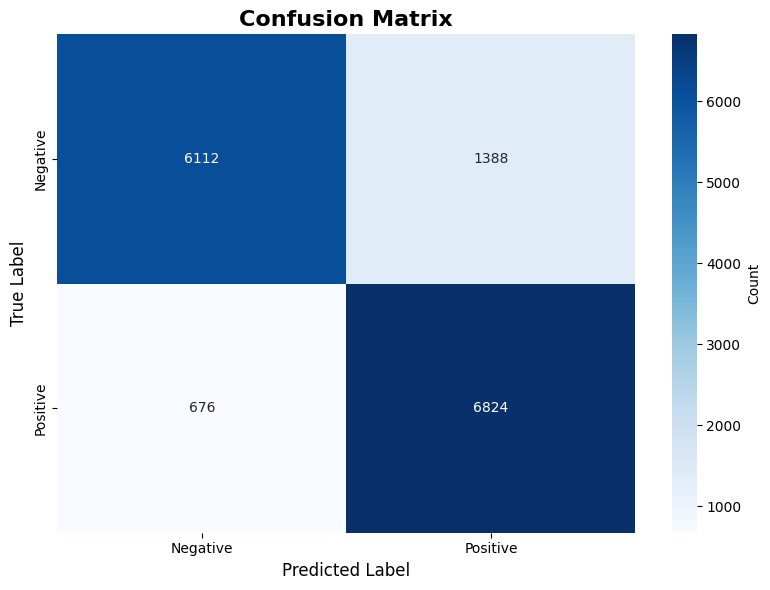


True Negatives: 6112
False Positives: 1388
False Negatives: 676
True Positives: 6824


In [12]:
# ============================================================================
# CELL 12: Confusion Matrix
# ============================================================================
print("\n" + "="*70)
print("CONFUSION MATRIX")
print("="*70)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")


ROC CURVE AND AUC SCORE


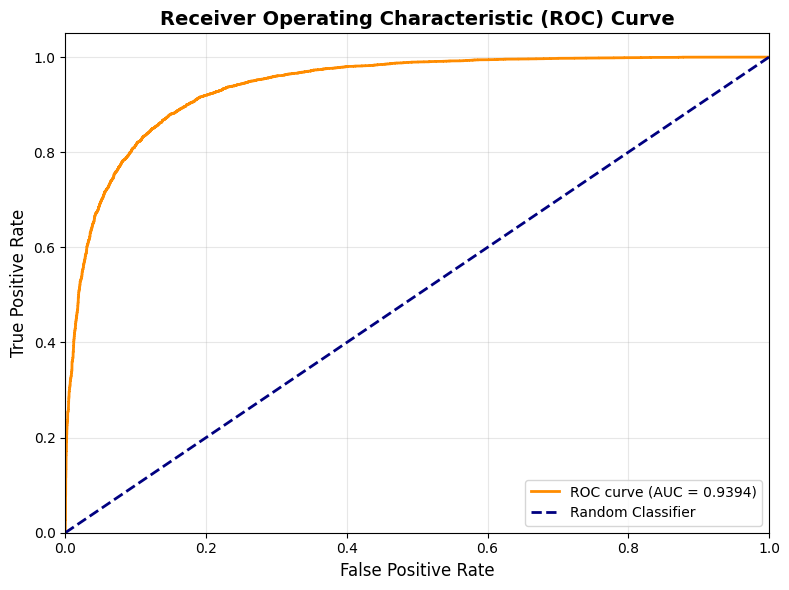


✓ ROC-AUC Score: 0.9394


In [13]:
# ============================================================================
# CELL 13: ROC Curve and AUC Score
# ============================================================================
print("\n" + "="*70)
print("ROC CURVE AND AUC SCORE")
print("="*70)

roc_auc = roc_auc_score(y_test, y_pred_prob)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n✓ ROC-AUC Score: {roc_auc:.4f}")

In [14]:
# ============================================================================
# CELL 14: Prediction Function
# ============================================================================
print("\n" + "="*70)
print("CREATING PREDICTION FUNCTION")
print("="*70)

def predict_sentiment(text):
    """
    Predict sentiment of a given text
    
    Args:
        text (str): Review text to analyze
        
    Returns:
        tuple: (sentiment_label, confidence_score)
    """
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post')
    pred = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive" if pred > 0.5 else "Negative"
    return sentiment, pred

print("✓ Prediction function created")


CREATING PREDICTION FUNCTION
✓ Prediction function created


In [15]:
# ============================================================================
# CELL 15: Test on Random Samples from Test Set
# ============================================================================
print("\n" + "="*70)
print("TESTING ON RANDOM SAMPLES FROM TEST SET")
print("="*70)

np.random.seed(42)
random_indices = np.random.choice(len(X_test), size=5, replace=False)

for i, idx in enumerate(random_indices, 1):
    original_review = X_test[idx]
    true_label = "Positive" if y_test[idx] == 1 else "Negative"
    pred_label, confidence = predict_sentiment(original_review)
    is_correct = "✓" if true_label == pred_label else "✗"
    
    print(f"\n[Sample {i}] {is_correct}")
    print(f"Review: {original_review[:150]}...")
    print(f"True: {true_label} | Predicted: {pred_label} | Confidence: {confidence:.4f}")
    print("-"*70)


TESTING ON RANDOM SAMPLES FROM TEST SET

[Sample 1] ✗
Review: demer daves is a wonderful director when it comes to westerns and broken arrow remains in everybody s mind as far as melodrama is concerned he should ...
True: Negative | Predicted: Positive | Confidence: 0.5818
----------------------------------------------------------------------

[Sample 2] ✓
Review: i sat down to watch this movie with my friends with very low expectations my expectations were no where near low enough i honestly could not tell what...
True: Negative | Predicted: Negative | Confidence: 0.0254
----------------------------------------------------------------------

[Sample 3] ✓
Review: creep your journey terminates here some very graphic scenes and well yeah that s about all for this film no real plot no storyline no likable characte...
True: Negative | Predicted: Negative | Confidence: 0.1044
----------------------------------------------------------------------

[Sample 4] ✓
Review: seriously what the hel

In [16]:
# ============================================================================
# CELL 16: Test on Custom Examples
# ============================================================================
print("\n" + "="*70)
print("TESTING ON CUSTOM EXAMPLES")
print("="*70)

test_reviews = [
    "This movie was absolutely amazing! I loved every minute of it.",
    "Terrible film, waste of time and money. Very disappointing.",
    "Not bad, but could have been better. Average movie overall.",
    "Brilliant performance by the actors. Must watch!",
    "Boring and predictable. I fell asleep halfway through."
]

for i, review in enumerate(test_reviews, 1):
    sentiment, confidence = predict_sentiment(review)
    print(f"\n[Example {i}]")
    print(f"Review: {review}")
    print(f"Prediction: {sentiment} (Confidence: {confidence:.4f})")



TESTING ON CUSTOM EXAMPLES

[Example 1]
Review: This movie was absolutely amazing! I loved every minute of it.
Prediction: Positive (Confidence: 0.8787)

[Example 2]
Review: Terrible film, waste of time and money. Very disappointing.
Prediction: Negative (Confidence: 0.0207)

[Example 3]
Review: Not bad, but could have been better. Average movie overall.
Prediction: Negative (Confidence: 0.1815)

[Example 4]
Review: Brilliant performance by the actors. Must watch!
Prediction: Positive (Confidence: 0.8019)

[Example 5]
Review: Boring and predictable. I fell asleep halfway through.
Prediction: Negative (Confidence: 0.0723)


In [17]:
# ============================================================================
# CELL 17: Edge Cases Testing
# ============================================================================
print("\n" + "="*70)
print("EDGE CASES TESTING")
print("="*70)

edge_cases = [
    ("Very short", "great"),
    ("Very negative", "horrible awful disgusting terrible worst"),
    ("Very positive", "amazing wonderful fantastic excellent superb"),
    ("Mixed signals", "The acting was good but the plot was bad"),
    ("Neutral/Ambiguous", "okay fine average nothing special mediocre"),
    ("Double negative", "not bad"),
    ("Negated positive", "not good")
]

for case_name, review in edge_cases:
    sentiment, confidence = predict_sentiment(review)
    print(f"\n[{case_name}]")
    print(f"Review: '{review}'")
    print(f"Prediction: {sentiment} (Confidence: {confidence:.4f})")


EDGE CASES TESTING

[Very short]
Review: 'great'
Prediction: Positive (Confidence: 0.8251)

[Very negative]
Review: 'horrible awful disgusting terrible worst'
Prediction: Negative (Confidence: 0.0144)

[Very positive]
Review: 'amazing wonderful fantastic excellent superb'
Prediction: Positive (Confidence: 0.9107)

[Mixed signals]
Review: 'The acting was good but the plot was bad'
Prediction: Negative (Confidence: 0.4248)

[Neutral/Ambiguous]
Review: 'okay fine average nothing special mediocre'
Prediction: Negative (Confidence: 0.1711)

[Double negative]
Review: 'not bad'
Prediction: Positive (Confidence: 0.6625)

[Negated positive]
Review: 'not good'
Prediction: Positive (Confidence: 0.7807)



CONFIDENCE DISTRIBUTION ANALYSIS


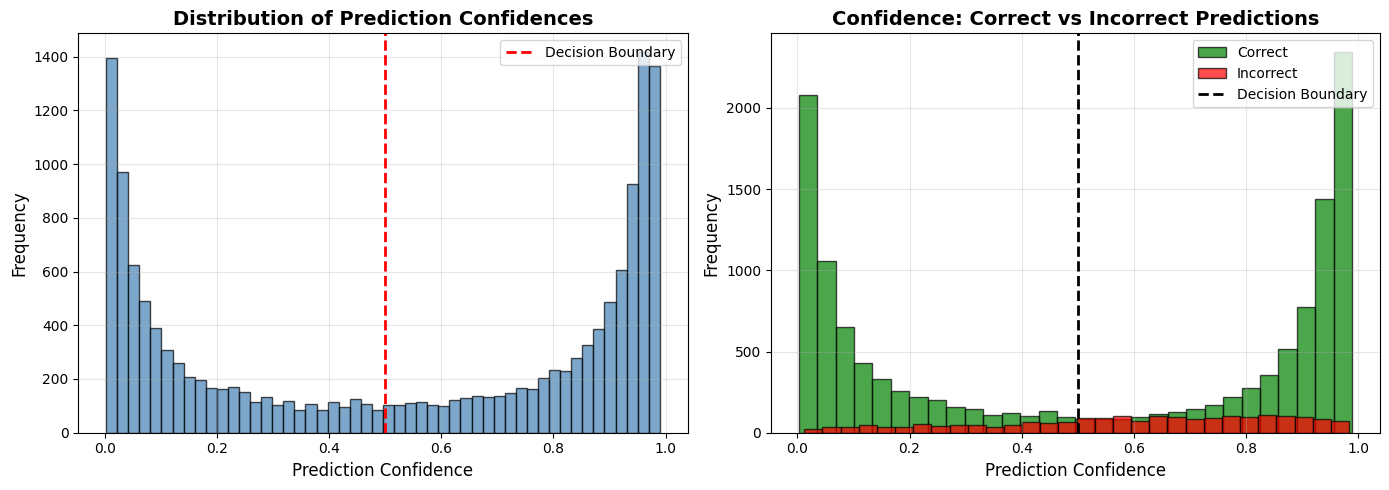


High Confidence Predictions (>0.7 or <0.3): 12776 (85.17%)
  - Correct: 11613 (90.90%)

Low Confidence Predictions (0.3-0.7): 2224 (14.83%)


In [18]:
# ============================================================================
# CELL 18: Confidence Distribution Analysis
# ============================================================================
print("\n" + "="*70)
print("CONFIDENCE DISTRIBUTION ANALYSIS")
print("="*70)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(y_pred_prob, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary')
plt.xlabel('Prediction Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Prediction Confidences', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
correct_preds = y_pred_prob[y_test == y_pred]
incorrect_preds = y_pred_prob[y_test != y_pred]
plt.hist(correct_preds, bins=30, alpha=0.7, label='Correct', edgecolor='black', color='green')
plt.hist(incorrect_preds, bins=30, alpha=0.7, label='Incorrect', edgecolor='black', color='red')
plt.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Boundary')
plt.xlabel('Prediction Confidence', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Confidence: Correct vs Incorrect Predictions', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

high_conf_correct = np.sum((y_pred_prob > 0.7) & (y_test == y_pred)) + np.sum((y_pred_prob < 0.3) & (y_test == y_pred))
high_conf_total = np.sum((y_pred_prob > 0.7) | (y_pred_prob < 0.3))
low_conf = np.sum((y_pred_prob >= 0.3) & (y_pred_prob <= 0.7))

print(f"\nHigh Confidence Predictions (>0.7 or <0.3): {high_conf_total} ({high_conf_total/len(y_test)*100:.2f}%)")
print(f"  - Correct: {high_conf_correct} ({high_conf_correct/high_conf_total*100:.2f}%)")
print(f"\nLow Confidence Predictions (0.3-0.7): {low_conf} ({low_conf/len(y_test)*100:.2f}%)")


In [19]:
# ============================================================================
# CELL 19: Error Analysis
# ============================================================================
print("\n" + "="*70)
print("ERROR ANALYSIS - MOST CONFIDENT MISTAKES")
print("="*70)

mistakes = np.where(y_test != y_pred)[0]
mistake_confidences = np.abs(y_pred_prob[mistakes] - 0.5)
top_mistakes_idx = mistakes[np.argsort(mistake_confidences)[-5:]][::-1]

for i, idx in enumerate(top_mistakes_idx, 1):
    print(f"\n[Mistake {i}]")
    print(f"Review: {X_test[idx][:250]}...")
    print(f"True: {'Positive' if y_test[idx]==1 else 'Negative'} | "
          f"Predicted: {'Positive' if y_pred[idx]==1 else 'Negative'} | "
          f"Confidence: {y_pred_prob[idx]:.4f}")
    print("-"*70)


ERROR ANALYSIS - MOST CONFIDENT MISTAKES

[Mistake 1]
Review: ernest borgnine was so wasted in this movie there was no point in putting this great actor in this movie one of the greatest actors in the world wasted and for what reason none what so ever so america if you want to put classic actors in movies don t...
True: Positive | Predicted: Negative | Confidence: 0.0123
----------------------------------------------------------------------

[Mistake 2]
Review: this movie is horrible in a so bad it s good kind of way the storyline is rehashed from so many other films of this kind that i m not going to even bother describing it it s a sword sorcery picture has a kid hoping to realize how important he is in t...
True: Positive | Predicted: Negative | Confidence: 0.0151
----------------------------------------------------------------------

[Mistake 3]
Review: this flick is sterling example of the state of erotic b movies bad porn movies without the hardcore sex the plot in this one isn 


PERFORMANCE BY REVIEW LENGTH
Length    0-50   words: Samples=  331 (  2.2%) | Accuracy=0.9003
Length   50-100  words: Samples= 1454 (  9.7%) | Accuracy=0.9023
Length  100-200  words: Samples= 6898 ( 46.0%) | Accuracy=0.8795
Length  200-500  words: Samples= 5074 ( 33.8%) | Accuracy=0.8419
Length  500-10000 words: Samples= 1243 (  8.3%) | Accuracy=0.7940


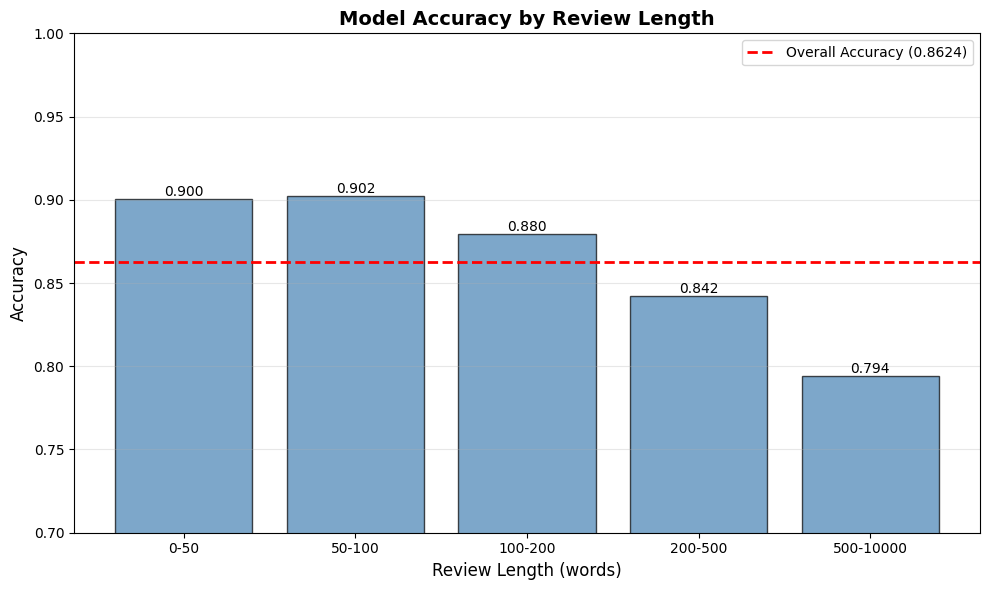

In [20]:
# ============================================================================
# CELL 20: Performance by Review Length
# ============================================================================
print("\n" + "="*70)
print("PERFORMANCE BY REVIEW LENGTH")
print("="*70)

review_lengths = [len(review.split()) for review in X_test]
length_bins = [(0, 50), (50, 100), (100, 200), (200, 500), (500, 10000)]

length_stats = []
for min_len, max_len in length_bins:
    mask = [(l >= min_len and l < max_len) for l in review_lengths]
    if sum(mask) > 0:
        acc = np.mean(y_test[mask] == y_pred[mask])
        count = sum(mask)
        length_stats.append({
            'Range': f'{min_len}-{max_len}',
            'Samples': count,
            'Accuracy': acc,
            'Percentage': count/len(review_lengths)*100
        })
        print(f"Length {min_len:>4}-{max_len:<4} words: "
              f"Samples={count:>5} ({count/len(review_lengths)*100:>5.1f}%) | "
              f"Accuracy={acc:.4f}")

# Visualize performance by length
lengths_cat = []
accuracies = []
for stat in length_stats:
    lengths_cat.append(stat['Range'])
    accuracies.append(stat['Accuracy'])

plt.figure(figsize=(10, 6))
bars = plt.bar(lengths_cat, accuracies, color='steelblue', edgecolor='black', alpha=0.7)
plt.axhline(y=test_acc, color='red', linestyle='--', linewidth=2, label=f'Overall Accuracy ({test_acc:.4f})')
plt.xlabel('Review Length (words)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Accuracy by Review Length', fontsize=14, fontweight='bold')
plt.ylim([0.7, 1.0])
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}',
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [21]:
# ============================================================================
# CELL 21: Save Model
# ============================================================================
print("\n" + "="*70)
print("SAVING MODEL")
print("="*70)

model.save('imdb_lstm_model.h5')
print("✓ Model saved as 'imdb_lstm_model.h5'")

# Save tokenizer
import pickle
with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)
print("✓ Tokenizer saved as 'tokenizer.pickle'")


SAVING MODEL
✓ Model saved as 'imdb_lstm_model.h5'
✓ Tokenizer saved as 'tokenizer.pickle'


In [22]:
# ============================================================================
# CELL 22: Final Summary
# ============================================================================
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print(f"""
Model Configuration:
  - Architecture: Bidirectional LSTM
  - Vocabulary Size: {max_words}
  - Max Sequence Length: {max_len}
  - Embedding Dimension: 128
  - Total Parameters: {total_params:,}

Dataset Split:
  - Training: {len(X_train)} samples (70%)
  - Testing: {len(X_test)} samples (30%)

Performance Metrics:
  - Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)
  - Test Loss: {test_loss:.4f}
  - ROC-AUC Score: {roc_auc:.4f}

Files Saved:
  - imdb_lstm_model.h5
  - tokenizer.pickle
""")
print("="*70)
print("✓ ALL TESTING COMPLETED SUCCESSFULLY!")
print("="*70)


FINAL SUMMARY

Model Configuration:
  - Architecture: Bidirectional LSTM
  - Vocabulary Size: 10000
  - Max Sequence Length: 10000
  - Embedding Dimension: 128
  - Total Parameters: 1,424,257

Dataset Split:
  - Training: 35000 samples (70%)
  - Testing: 15000 samples (30%)

Performance Metrics:
  - Test Accuracy: 0.8624 (86.24%)
  - Test Loss: 0.3209
  - ROC-AUC Score: 0.9394

Files Saved:
  - imdb_lstm_model.h5
  - tokenizer.pickle

✓ ALL TESTING COMPLETED SUCCESSFULLY!



TRAIN VS TEST PERFORMANCE COMPARISON

Evaluating model on training data...

PERFORMANCE METRICS COMPARISON

        Metric        Training         Testing Difference
     Accuracy 0.9128 (91.28%) 0.8624 (86.24%)     0.0504
         Loss          0.2369          0.3209     0.0840
ROC-AUC Score          0.9708          0.9394     0.0314

MODEL FITTING ANALYSIS

⚠️  OVERFITTING DETECTED
   - Training accuracy is 5.04% higher than test accuracy
   - Model may have memorized training data

   Recommendations:
   • Increase dropout rate
   • Add more regularization (L1/L2)
   • Reduce model complexity
   • Collect more training data


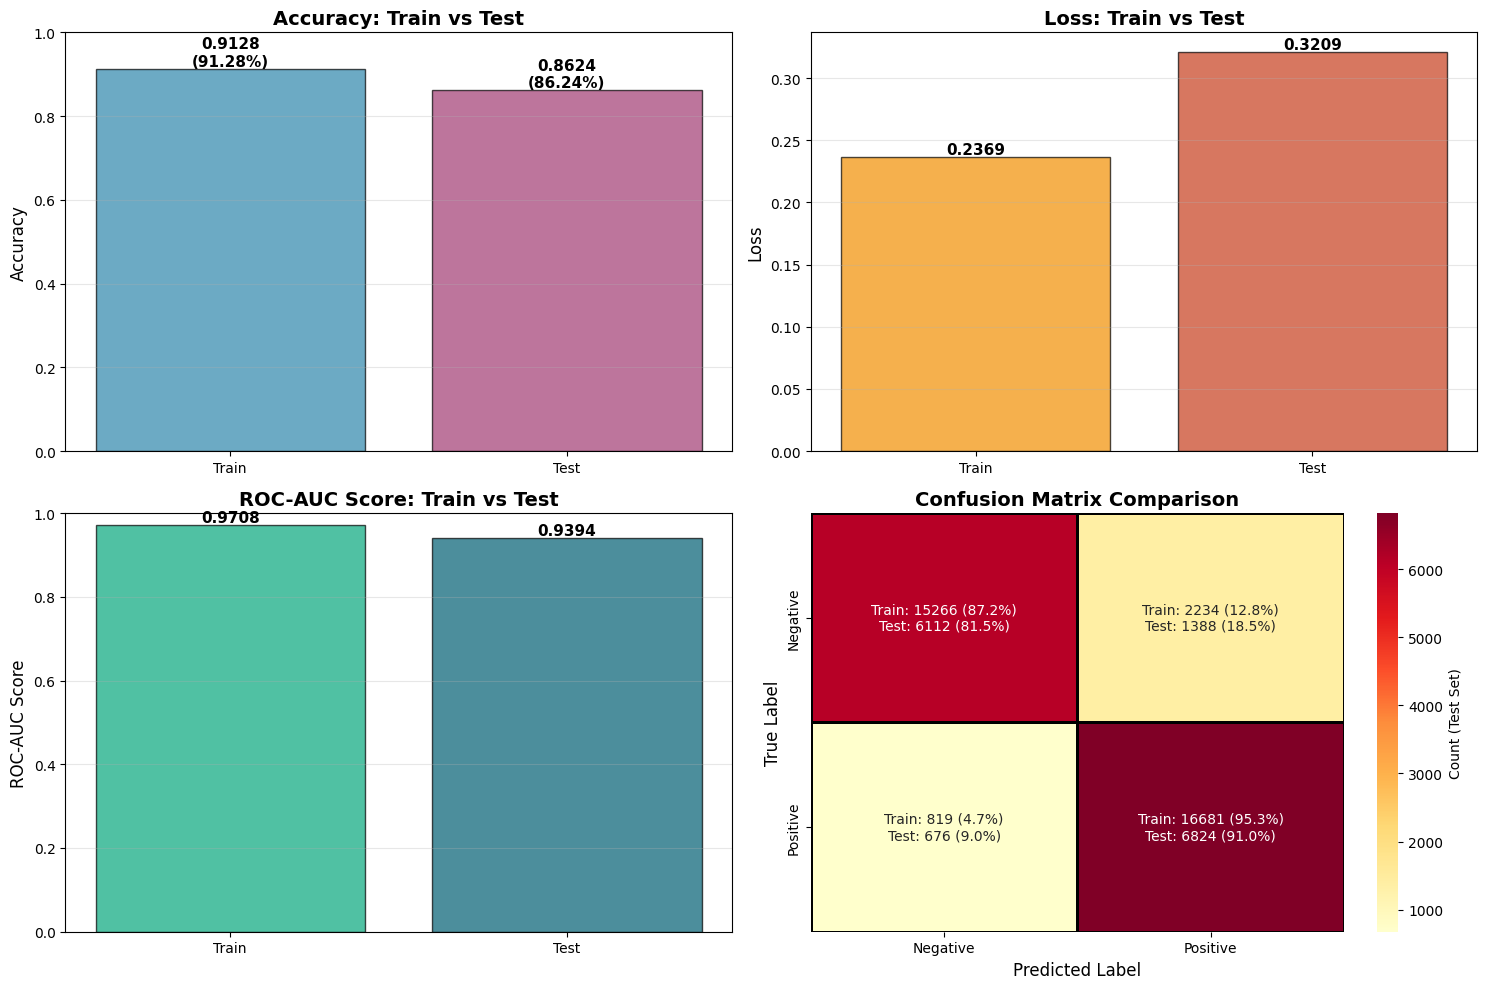


DETAILED CLASSIFICATION METRICS

--- TRAINING SET ---
              precision    recall  f1-score   support

    Negative       0.95      0.87      0.91     17500
    Positive       0.88      0.95      0.92     17500

    accuracy                           0.91     35000
   macro avg       0.92      0.91      0.91     35000
weighted avg       0.92      0.91      0.91     35000


--- TESTING SET ---
              precision    recall  f1-score   support

    Negative       0.90      0.81      0.86      7500
    Positive       0.83      0.91      0.87      7500

    accuracy                           0.86     15000
   macro avg       0.87      0.86      0.86     15000
weighted avg       0.87      0.86      0.86     15000


DATASET SIZE COMPARISON

Training samples: 35,000
Testing samples: 15,000
Train/Test ratio: 2.33:1

✓ TRAIN VS TEST COMPARISON COMPLETED!


In [23]:
# ============================================================================
# CELL 23: Train vs Test Performance Comparison
# ============================================================================
print("\n" + "="*70)
print("TRAIN VS TEST PERFORMANCE COMPARISON")
print("="*70)

# Evaluate on training data
print("\nEvaluating model on training data...")
train_loss, train_acc = model.evaluate(X_train_pad, y_train, verbose=0)
y_train_pred_prob = model.predict(X_train_pad, verbose=0).flatten()
y_train_pred = (y_train_pred_prob > 0.5).astype(int)
train_roc_auc = roc_auc_score(y_train, y_train_pred_prob)

# Test metrics (already computed)
test_roc_auc = roc_auc

# Create comparison table
print("\n" + "="*70)
print("PERFORMANCE METRICS COMPARISON")
print("="*70)

comparison_data = {
    'Metric': ['Accuracy', 'Loss', 'ROC-AUC Score'],
    'Training': [f'{train_acc:.4f} ({train_acc*100:.2f}%)', 
                 f'{train_loss:.4f}', 
                 f'{train_roc_auc:.4f}'],
    'Testing': [f'{test_acc:.4f} ({test_acc*100:.2f}%)', 
                f'{test_loss:.4f}', 
                f'{test_roc_auc:.4f}'],
    'Difference': [f'{abs(train_acc - test_acc):.4f}', 
                   f'{abs(train_loss - test_loss):.4f}', 
                   f'{abs(train_roc_auc - test_roc_auc):.4f}']
}

comparison_df = pd.DataFrame(comparison_data)
print("\n", comparison_df.to_string(index=False))

# Overfitting/Underfitting Analysis
print("\n" + "="*70)
print("MODEL FITTING ANALYSIS")
print("="*70)

acc_diff = train_acc - test_acc
loss_diff = train_loss - test_loss

if acc_diff > 0.05 or loss_diff < -0.1:
    print("\n⚠️  OVERFITTING DETECTED")
    print(f"   - Training accuracy is {acc_diff*100:.2f}% higher than test accuracy")
    print(f"   - Model may have memorized training data")
    print("\n   Recommendations:")
    print("   • Increase dropout rate")
    print("   • Add more regularization (L1/L2)")
    print("   • Reduce model complexity")
    print("   • Collect more training data")
elif acc_diff < -0.05:
    print("\n⚠️  UNDERFITTING DETECTED")
    print(f"   - Test accuracy is {abs(acc_diff)*100:.2f}% higher than training accuracy")
    print("\n   Recommendations:")
    print("   • Increase model complexity")
    print("   • Train for more epochs")
    print("   • Reduce regularization")
else:
    print("\n✓ GOOD FIT")
    print(f"   - Training and testing performance are well balanced")
    print(f"   - Accuracy difference: {acc_diff*100:.2f}%")
    print(f"   - Model generalizes well to unseen data")

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Accuracy Comparison
metrics = ['Train', 'Test']
accuracies = [train_acc, test_acc]
colors_acc = ['#2E86AB', '#A23B72']
bars1 = axes[0, 0].bar(metrics, accuracies, color=colors_acc, edgecolor='black', alpha=0.7)
axes[0, 0].set_ylabel('Accuracy', fontsize=12)
axes[0, 0].set_title('Accuracy: Train vs Test', fontsize=14, fontweight='bold')
axes[0, 0].set_ylim([0, 1.0])
axes[0, 0].grid(axis='y', alpha=0.3)
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}\n({height*100:.2f}%)',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# 2. Loss Comparison
losses = [train_loss, test_loss]
colors_loss = ['#F18F01', '#C73E1D']
bars2 = axes[0, 1].bar(metrics, losses, color=colors_loss, edgecolor='black', alpha=0.7)
axes[0, 1].set_ylabel('Loss', fontsize=12)
axes[0, 1].set_title('Loss: Train vs Test', fontsize=14, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# 3. ROC-AUC Comparison
roc_aucs = [train_roc_auc, test_roc_auc]
colors_roc = ['#06A77D', '#005F73']
bars3 = axes[1, 0].bar(metrics, roc_aucs, color=colors_roc, edgecolor='black', alpha=0.7)
axes[1, 0].set_ylabel('ROC-AUC Score', fontsize=12)
axes[1, 0].set_title('ROC-AUC Score: Train vs Test', fontsize=14, fontweight='bold')
axes[1, 0].set_ylim([0, 1.0])
axes[1, 0].grid(axis='y', alpha=0.3)
for bar in bars3:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.4f}',
                    ha='center', va='bottom', fontsize=11, fontweight='bold')

# 4. Confusion Matrix Comparison
cm_train = confusion_matrix(y_train, y_train_pred)
cm_test = confusion_matrix(y_test, y_pred)

# Normalize confusion matrices for better comparison
cm_train_norm = cm_train.astype('float') / cm_train.sum(axis=1)[:, np.newaxis]
cm_test_norm = cm_test.astype('float') / cm_test.sum(axis=1)[:, np.newaxis]

# Create text for heatmap
cm_train_text = np.array([[f'{cm_train[i,j]}\n({cm_train_norm[i,j]:.2%})' 
                           for j in range(2)] for i in range(2)])
cm_test_text = np.array([[f'{cm_test[i,j]}\n({cm_test_norm[i,j]:.2%})' 
                          for j in range(2)] for i in range(2)])

# Plot side by side comparison
comparison_text = np.array([[f'Train: {cm_train[i,j]} ({cm_train_norm[i,j]:.1%})\nTest: {cm_test[i,j]} ({cm_test_norm[i,j]:.1%})' 
                             for j in range(2)] for i in range(2)])

sns.heatmap(cm_test, annot=comparison_text, fmt='', cmap='YlOrRd', 
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'],
            cbar_kws={'label': 'Count (Test Set)'},
            ax=axes[1, 1], linewidths=2, linecolor='black')
axes[1, 1].set_title('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('True Label', fontsize=12)
axes[1, 1].set_xlabel('Predicted Label', fontsize=12)

plt.tight_layout()
plt.show()

# Detailed metrics comparison
print("\n" + "="*70)
print("DETAILED CLASSIFICATION METRICS")
print("="*70)

print("\n--- TRAINING SET ---")
print(classification_report(y_train, y_train_pred, target_names=['Negative', 'Positive']))

print("\n--- TESTING SET ---")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Sample size comparison
print("\n" + "="*70)
print("DATASET SIZE COMPARISON")
print("="*70)
print(f"\nTraining samples: {len(y_train):,}")
print(f"Testing samples: {len(y_test):,}")
print(f"Train/Test ratio: {len(y_train)/len(y_test):.2f}:1")

print("\n" + "="*70)
print("✓ TRAIN VS TEST COMPARISON COMPLETED!")
print("="*70)